In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(42)

In [3]:
df=pd.read_csv("data/fashion-mnist_test.csv")

In [4]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


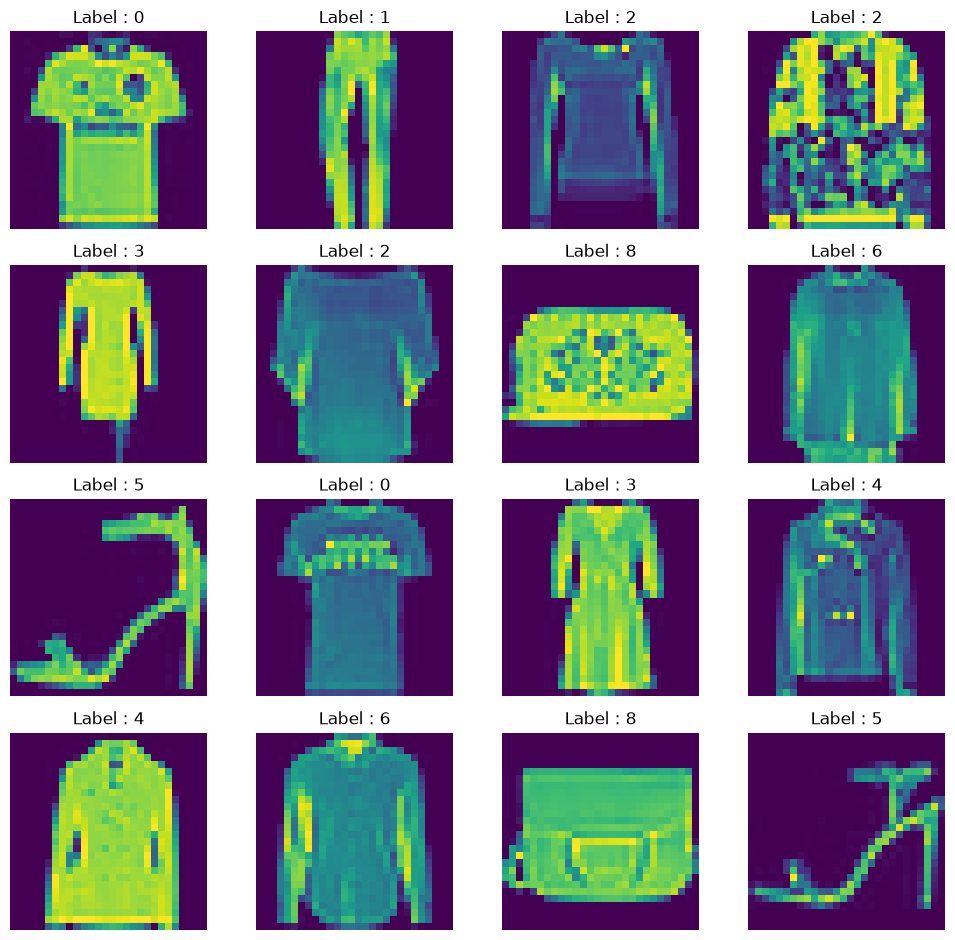

In [7]:
# create a 4*4 grid of images
fig,axes = plt.subplots(4,4,figsize=(10,10))

# plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i,1:].values.reshape(28,28)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'Label : {df.iloc[i,0]}')

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


In [8]:
#train test split
X=df.iloc[:,1:].values
y=df.iloc[:,0].values
X_train,X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=13)
X_train = X_train/255.0
X_test = X_test/255.0

In [9]:
## create the Custom Dataset class

class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels =  torch.tensor(labels, dtype = torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        return self.features[index], self.labels[index]

In [10]:
## create the train dataset object

train_dataset = CustomDataset(X_train, y_train)

In [11]:
len(train_dataset)

8000

In [12]:
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.1412, 0.1922, 0.3333,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0078, 0.0000, 0.0000, 0.0235, 0.0000, 0.1059, 0.2941, 0.3843,
         0.5529, 0.6275, 0.2353, 0.0000, 0.0000, 0.1333, 0.3098, 0.1843, 0.3922,
         0.3529, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0078, 0.0000, 0.1647, 0.6549,
         0.5961, 0.5451, 1.0000, 0.7529, 0.0000, 0.0000, 0.5098, 0.7216, 0.5294,
         0.5294, 0.5020, 0.0

In [13]:
test_dataset = CustomDataset(X_test, y_test)
print(len(test_dataset))

2000


In [14]:
## create train and test dataloaders 
train_loader = DataLoader(train_dataset, batch_size=32, shuffle = True )
test_loader = DataLoader(test_dataset, batch_size=32, shuffle = False )

In [ ]:
## define NN class 